# 03. Li diffusion in Li–Y–Cl from seven foundation potentials

**System.** Li<sub>15</sub>Y<sub>7</sub>Cl<sub>36</sub> (58 atoms), the cell used for the in-house AIMD
data (not the stoichiometric Li<sub>3</sub>YCl<sub>6</sub> cell).

**MD (identical for every FP).** ASE, NVT with a Nosé–Hoover chain thermostat (chain length 3,
τ = 100 fs), 2 fs time step, frames stored every 200 fs. 40 temperatures from 300 to 1025 K, evenly
spaced in 1/T. Each temperature was run as 1–4 consecutive 400 ps jobs; the later jobs continue the
previous one (new Maxwell–Boltzmann velocities), so they are analyzed as one trajectory. The first
20 ps are discarded as equilibration.

**Foundation potentials.** MACE-MPA-0 (medium), CHGNet (pretrained), M3GNet-MP-2021.2.8-PES,
UMA s1.1 (omat task), M3GNet-MatPES-PBE, TensorNet-MatPES-PBE (both v2025.1) and MACE-MatPES-PBE.

### Diffusion analysis (same for every MD notebook in this repository)

Implemented in `iondiff/` (adapted from the MoGroup diffusion module; method of X. He, Y. Zhu, A. Epstein,
Y. Mo, *npj Comput. Mater.* **4**, 18 (2018)):

* **Trajectory**: jobs that continue a previous job (first frame identical to the previous last frame)
  are concatenated after dropping the duplicated frame; equilibration frames are removed only at the
  start of each chain. NPT displacements use each frame's own cell.
* **MSD**: time-averaged (FFT) mean squared displacement of the mobile ion, with the framework
  centre-of-mass drift removed; fitted linearly between MSD = 0.5 a² and 0.8 of the trajectory length
  (a = 3.38 Å, average hop distance), requiring at least 0.5 a² of MSD change. D = slope / 6.
* **Statistical error of D**: RSD = 3.43 / √N<sub>jump</sub> + 0.04 with N<sub>jump</sub> = n<sub>ions</sub>
  · max(MSD) / a² (He et al. 2018); σ<sub>D</sub> = RSD · D.
* **Framework melting**: a temperature is marked *melted* when the framework (all non-mobile atoms)
  diffuses, i.e. their time-averaged MSD at the end of the fit window exceeds a². Isolated framework
  hops (a few atoms moving > 4 Å) do not count; they are recorded separately.
* **Arrhenius fit (primary)**: least squares on log<sub>10</sub>D vs 1000/T, weighted by
  σ<sub>log10 D</sub>, using temperatures where the MSD fit succeeded and the framework did not melt.
  Fits that keep melted temperatures, and unweighted fits, are shown for comparison.
* **Conductivity**: Nernst–Einstein, σ = n z² e² D / (V k<sub>B</sub> T); σ(300 K) is extrapolated
  from the fit (the range comes from the fit uncertainty).

In [1]:
import numpy as np
import pandas as pd
from plot_style import plt, save, PALETTE
import md_results as mr

doc = mr.load("lyc_7fp_nvt")
curves = mr.load_curves("lyc_7fp_nvt")
labels = [s["label"] for s in doc["series"]]
mr.summary_table(doc)

,temperatures,total analyzed time (ns),MSD fit ok,framework melted,T used in fit (K),Ea (eV),Ea std (eV),R2,sigma(300 K) extrapolated (mS/cm),sigma(300 K) range (mS/cm)
model,,,,,,,,,,
MACE-MPA-0 (medium),40,37.2,34,0,330-1025 (34),0.197,0.007,0.941,9.44,6.90-12.92
CHGNet (pretrained),40,33.2,34,5,300-783 (29),0.225,0.008,0.959,9.94,6.86-14.39
M3GNet-MP-2021.2.8-PES,40,34.4,35,5,300-783 (30),0.178,0.008,0.904,20.96,14.46-30.39
UMA s1.1 (omat),40,34.8,33,0,344-1025 (33),0.195,0.006,0.936,15.20,11.65-19.84
M3GNet-MatPES-PBE,40,31.6,40,0,300-1025 (40),0.138,0.004,0.951,79.51,66.00-95.78
TensorNet-MatPES-PBE,40,36.4,36,0,323-1025 (36),0.209,0.006,0.979,10.92,8.34-14.30
MACE-MatPES-PBE,40,15.6,40,1,300-965 (39),0.147,0.006,0.904,59.24,45.74-76.73


'figures/md/lyc_7fp_arrhenius.png'

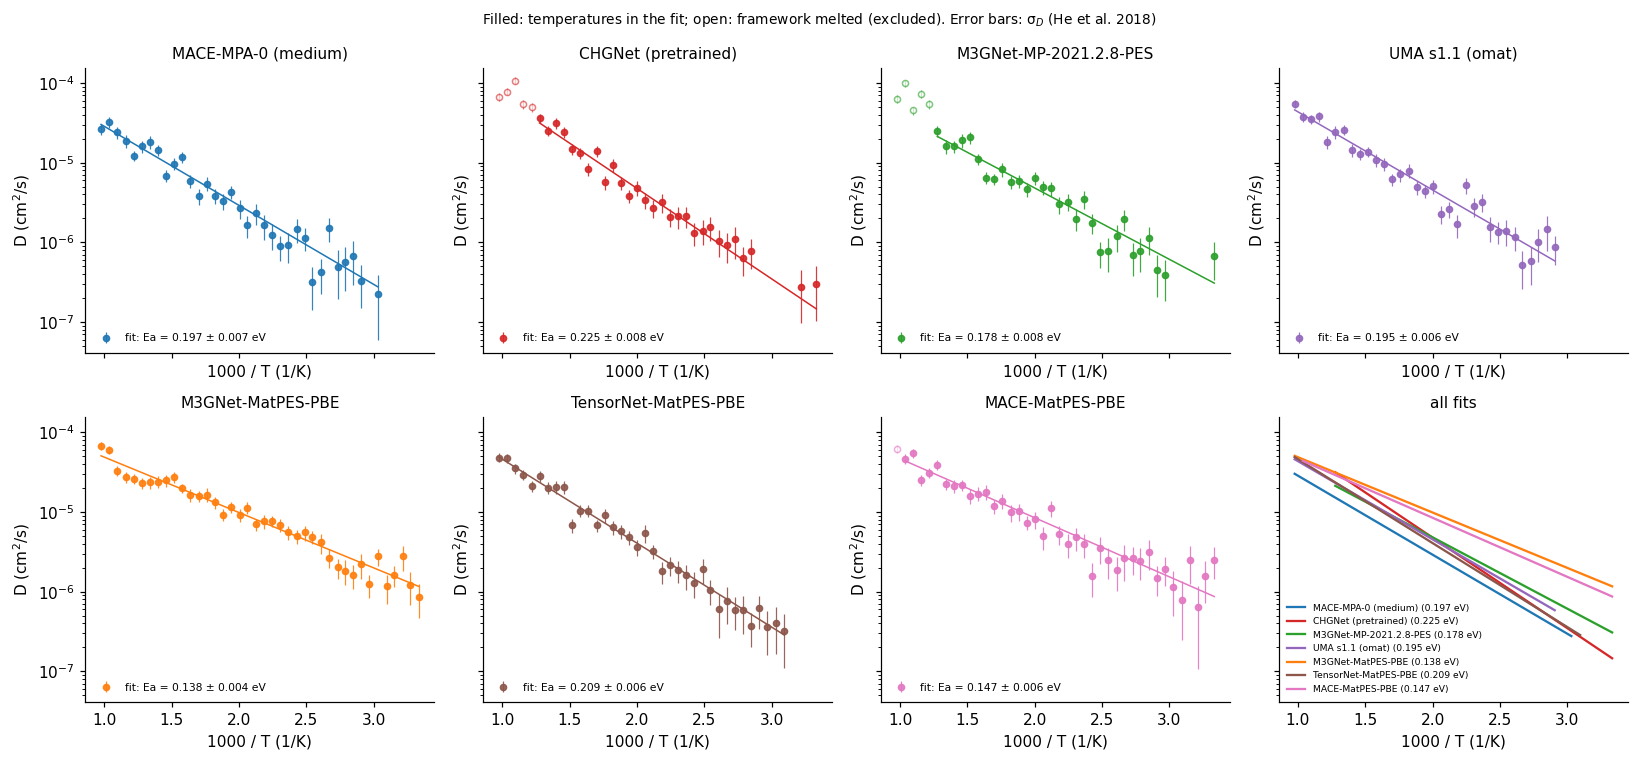

In [2]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7), sharex=True, sharey=True)
for ax, s, c in zip(axes.flat, doc["series"], PALETTE):
    mr.arrhenius_plot(ax, s, c, label="fit")
    ax.set_title(s["label"]); ax.legend(frameon=False, fontsize=7, loc="lower left")
ax = axes.flat[-1]
for s, c in zip(doc["series"], PALETTE):
    f = s["arrhenius"][mr.PRIMARY]
    xs = np.linspace(1000 / max(f["temperatures_used_K"]), 1000 / min(f["temperatures_used_K"]), 50)
    ax.plot(xs, 10 ** (f["slope"] * xs + f["intercept"]), color=c, label=f"{s['label']} ({f['Ea_eV']:.3f} eV)")
ax.set_yscale("log"); ax.set_title("all fits"); ax.legend(frameon=False, fontsize=6)
ax.set_xlabel("1000 / T (1/K)")
fig.suptitle("Filled: temperatures in the fit; open: framework melted (excluded). Error bars: σ$_D$ (He et al. 2018)", fontsize=9)
fig.tight_layout(); save(fig, "md/lyc_7fp_arrhenius")

## Sensitivity of E<sub>a</sub> to the fit choices

Columns: primary fit (weighted, melted temperatures excluded); the same with melted temperatures kept;
unweighted; and the 500–1000 K window.

In [3]:
mr.fit_comparison(doc, ["all (no framework melt)", "all", "all (unweighted)",
                        "500-1000K (no framework melt)", "500-1000K"])

,all (no framework melt),all,all (unweighted),500-1000K (no framework melt),500-1000K
MACE-MPA-0 (medium),0.197,0.197,0.200,0.199,0.199
CHGNet (pretrained),0.225,0.246,0.220,0.269,0.294
M3GNet-MP-2021.2.8-PES,0.178,0.223,0.202,0.217,0.297
UMA s1.1 (omat),0.195,0.195,0.188,0.211,0.211
M3GNet-MatPES-PBE,0.138,0.138,0.140,0.128,0.128
TensorNet-MatPES-PBE,0.209,0.209,0.209,0.211,0.211
MACE-MatPES-PBE,0.147,0.151,0.143,0.167,0.167


'figures/md/lyc_7fp_framework_displacement.png'

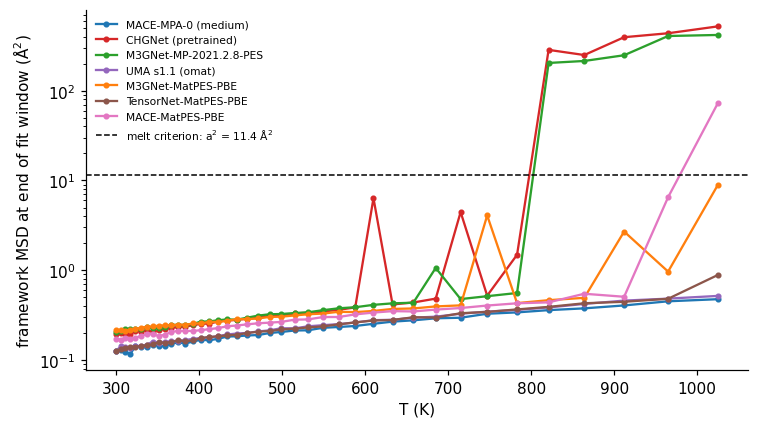

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
for s, c in zip(doc["series"], PALETTE):
    T = [r["temperature_K"] for r in s["temperatures"] if r.get("framework_msd_at_fit_end_A2")]
    d = [r["framework_msd_at_fit_end_A2"] for r in s["temperatures"] if r.get("framework_msd_at_fit_end_A2")]
    ax.plot(T, d, "o-", ms=3, color=c, label=s["label"])
ax.axhline(3.38 ** 2, color="k", ls="--", lw=1, label="melt criterion: a$^2$ = 11.4 Å$^2$")
ax.set_yscale("log"); ax.set_xlabel("T (K)"); ax.set_ylabel("framework MSD at end of fit window (Å$^2$)")
ax.legend(frameon=False, fontsize=7); fig.tight_layout(); save(fig, "md/lyc_7fp_framework_displacement")

## MSD curves (example: MACE-MPA-0)

Thin lines: MSD; thick translucent segment: the window used for the linear fit.

'figures/md/lyc_mace_mpa0_msd.png'

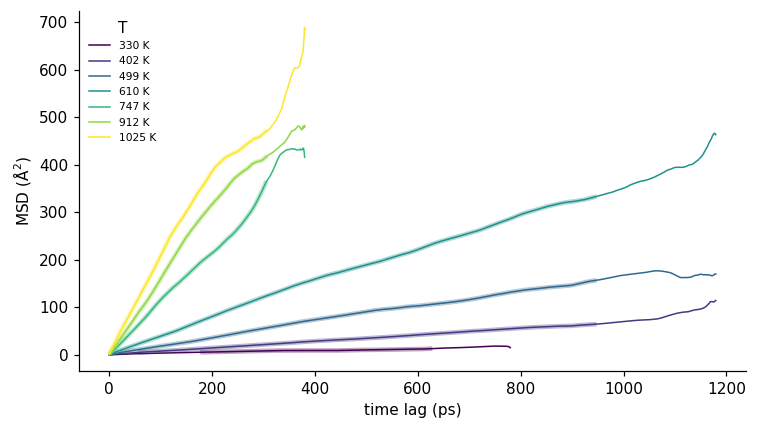

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
mr.msd_plot(ax, curves, "MACE-MPA-0 (medium)", [330, 402, 499, 610, 747, 912, 1025])
ax.legend(frameon=False, fontsize=7, title="T"); fig.tight_layout(); save(fig, "md/lyc_mace_mpa0_msd")

## Per-temperature results (example: CHGNet)

The same table is available for every model through `mr.per_temperature(mr.series(doc, label))`.

In [6]:
mr.per_temperature(mr.series(doc, "CHGNet (pretrained)"))

,status,analyzed time (ps),jobs (segments),D (cm2/s),D std (cm2/s),N_jump,max framework disp. (A),melted
T (K),,,,,,,,
300.0,ok,1180.0,3,3.026960e-07,2.007202e-07,30.301288,1.714808,False
306.0,msd_fit_requirements_not_met,380.0,1,NaN,NaN,NaN,1.427933,False
311.0,ok,1180.0,3,2.755745e-07,1.791208e-07,31.618582,1.593540,False
317.0,msd_fit_requirements_not_met,380.0,1,NaN,NaN,NaN,1.431753,False
323.0,msd_fit_requirements_not_met,380.0,1,NaN,NaN,NaN,1.457927,False
330.0,msd_fit_requirements_not_met,380.0,1,NaN,NaN,NaN,1.676145,False
337.0,msd_fit_requirements_not_met,380.0,1,NaN,NaN,NaN,1.656384,False
344.0,msd_fit_requirements_not_met,380.0,1,NaN,NaN,NaN,1.867506,False
351.0,ok,1180.0,3,7.758787e-07,3.175513e-07,86.273531,1.755409,False


## Comparison with AIMD (PBE)

The AIMD trajectories used to train the LYC models (VASP, PBE, NVT, 2 fs, 500–900 K, same 58-atom cell)
were analyzed with exactly the same code and fit settings (`results/aimd_lyc.json`). Squares: AIMD;
dashed line: AIMD fit. The table gives E<sub>a</sub> refitted over the AIMD temperature window only,
and the ratio of each model's fitted D to the AIMD D at each AIMD temperature (1 = agreement).

,Ea in AIMD window (eV),Ea std (eV),T used (K)
model,,,
AIMD (PBE),0.265,0.045,500-900 (5)
MACE-MPA-0 (medium),0.185,0.018,515-864 (14)
CHGNet (pretrained),0.269,0.020,515-783 (12)
M3GNet-MP-2021.2.8-PES,0.217,0.022,515-783 (12)
UMA s1.1 (omat),0.220,0.016,515-864 (14)
M3GNet-MatPES-PBE,0.104,0.015,515-864 (14)
TensorNet-MatPES-PBE,0.202,0.017,515-864 (14)
MACE-MatPES-PBE,0.148,0.017,515-864 (14)


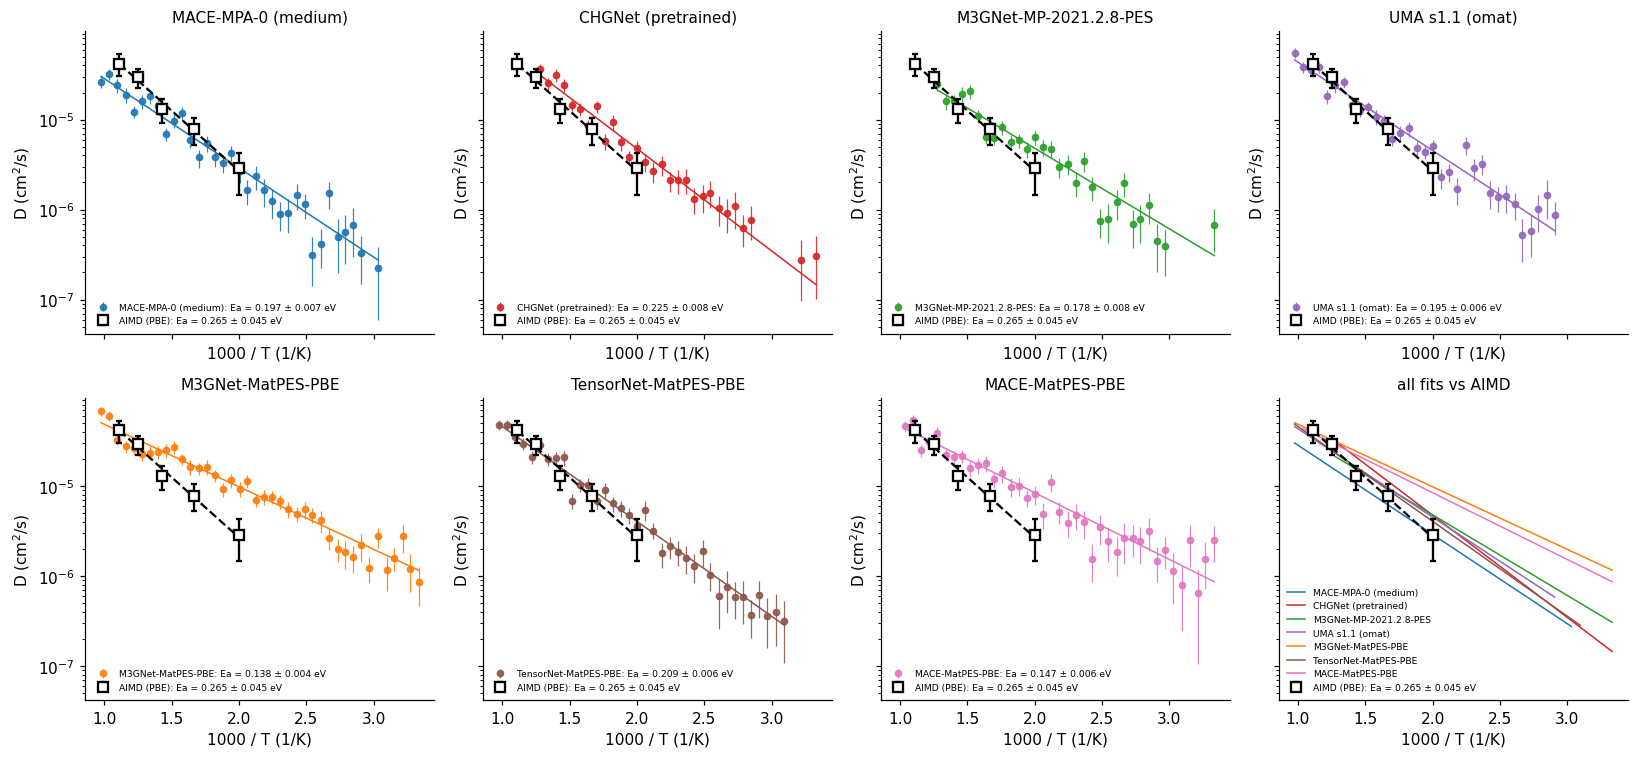

In [7]:
aimd = mr.series(mr.load("aimd_lyc"), "AIMD (PBE)")
fig, axes = plt.subplots(2, 4, figsize=(15, 7), sharex=True, sharey=True)
for ax, s, c in zip(axes.flat, doc["series"], PALETTE):
    mr.arrhenius_plot(ax, s, c, label=s["label"], show_melted=False)
    mr.aimd_overlay(ax, aimd)
    ax.set_title(s["label"]); ax.legend(frameon=False, fontsize=6, loc="lower left")
ax = axes.flat[-1]
mr.aimd_overlay(ax, aimd)
for s, c in zip(doc["series"], PALETTE):
    f = s["arrhenius"][mr.PRIMARY]; used = f["temperatures_used_K"]
    xs = np.linspace(1000 / max(used), 1000 / min(used), 50)
    ax.plot(xs, 10 ** (f["slope"] * xs + f["intercept"]), color=c, lw=1, label=s["label"])
ax.set_title("all fits vs AIMD"); ax.legend(frameon=False, fontsize=6); ax.set_xlabel("1000 / T (1/K)")
fig.tight_layout(); save(fig, "md/lyc_7fp_vs_aimd")
ea_table, ratio_table = mr.compare_to_aimd(doc["series"], aimd)
ea_table

In [8]:
ratio_table.round(2)

,D_FP/D_AIMD at 500 K,D_FP/D_AIMD at 600 K,D_FP/D_AIMD at 700 K,D_FP/D_AIMD at 800 K,D_FP/D_AIMD at 900 K
MACE-MPA-0 (medium),1.01,0.79,0.83,0.55,0.53
CHGNet (pretrained),1.65,1.45,1.63,NaN,NaN
M3GNet-MP-2021.2.8-PES,1.67,1.22,1.20,NaN,NaN
UMA s1.1 (omat),1.57,1.23,1.27,0.84,0.81
M3GNet-MatPES-PBE,3.41,2.14,1.89,1.11,0.98
TensorNet-MatPES-PBE,1.41,1.16,1.25,0.85,0.84
MACE-MatPES-PBE,2.93,1.90,1.73,1.03,0.92


## Findings

* **Spread across foundation potentials.** With the same cell, thermostat and analysis, the seven FPs
  give E<sub>a</sub> from 0.138 eV (M3GNet-MatPES-PBE) to 0.225 eV (CHGNet), and extrapolated
  σ(300 K) from 9.4 mS/cm (MACE-MPA-0) to 79.5 mS/cm (M3GNet-MatPES-PBE), an 8× range.
* **The two MatPES-PBE models that predict the fastest diffusion** (M3GNet-MatPES-PBE 0.138 eV,
  MACE-MatPES-PBE 0.147 eV) differ most from the rest; MACE-MPA-0, UMA s1.1 and TensorNet-MatPES-PBE
  cluster at 0.195–0.209 eV.
* **Framework melting changes the activation energy.** CHGNet and M3GNet-MP-2021.2.8-PES melt the
  Li–Y–Cl framework at 821 K and above (the framework MSD rises by more than two orders of magnitude). Keeping those temperatures in the
  fit raises E<sub>a</sub> from 0.225 to 0.246 eV (CHGNet) and from 0.178 to 0.223 eV (M3GNet-PES).
* **Fit choices matter for some models, not others.** For the five FPs whose framework stays solid,
  the weighted, unweighted and 500–1000 K fits span at most 0.024 eV (MACE-MPA-0 and TensorNet-MatPES-PBE
  only 0.003 eV); for CHGNet and M3GNet-PES they span 0.07 and 0.12 eV, and even with melted
  temperatures removed the 500–1000 K fit is 0.04 eV higher than the full-range fit.
* **The lowest temperatures are at the limit of these run lengths.** For five FPs, between 4 and 7
  temperatures in the 300–344 K range did not reach the minimum MSD for a fit (most were single 400 ps
  jobs, some two jobs) and are not used. Both MatPES models, which give the fastest diffusion, fit at
  all 40 temperatures.

**Against AIMD (PBE, same cell, 500–900 K):** AIMD gives E<sub>a</sub> = 0.265 ± 0.045 eV over
500–900 K. Refitted over the same window, CHGNet (0.269 eV), UMA s1.1 (0.220), M3GNet-PES (0.217) and
TensorNet-MatPES-PBE (0.202) agree with it within 1.3 combined standard deviations, MACE-MPA-0
(0.185 eV) within 1.7. The two MatPES models with the fastest diffusion are clearly lower
(MACE-MatPES-PBE 0.148 eV, 2.4σ; M3GNet-MatPES-PBE 0.104 eV, 3.4σ) and overestimate D at 500 K by
2.9× and 3.4×. At 600–900 K, every FP whose framework stays solid is within a factor of 2.2 of the
AIMD diffusivity. The AIMD E<sub>a</sub> itself is uncertain (5 temperatures, 68–204 ps each), so it
separates the FPs only coarsely.